In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# loading & preprocessing Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("frabbisw/facial-age")

print("Path to dataset files:", path)

100%|██████████| 840M/840M [00:50<00:00, 17.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/frabbisw/facial-age/versions/1


In [ ]:
!rm -r "$path"/face_age/face_age/

In [ ]:
!ls "$path"/face_age

001  008  015  022  029  036  043  050	057  064  071  078  085  092  110
002  009  016  023  030  037  044  051	058  065  072  079  086  093
003  010  017  024  031  038  045  052	059  066  073  080  087  095
004  011  018  025  032  039  046  053	060  067  074  081  088  096
005  012  019  026  033  040  047  054	061  068  075  082  089  099
006  013  020  027  034  041  048  055	062  069  076  083  090  100
007  014  021  028  035  042  049  056	063  070  077  084  091  101


In [ ]:
import tensorflow as tf
import os

# Define the path to the dataset
dataset_dir = path + "/face_age"

# Create a dataset using image_dataset_from_directory
# This function infers the labels from the directory structure
image_size = (200, 200)
batch_size = 32

# Create the initial dataset
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    labels='inferred',
    label_mode='int', # Use 'int' for integer labels (age)
    image_size=image_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True
)

# Get the number of classes
num_classes = len(dataset.class_names)

# Split the dataset into training, validation, and test sets
# You can adjust the split ratios as needed
train_size = int(0.7 * tf.data.experimental.cardinality(dataset).numpy())
val_size = int(0.15 * tf.data.experimental.cardinality(dataset).numpy())
test_size = int(0.15 * tf.data.experimental.cardinality(dataset).numpy())

train_ds = dataset.take(train_size)
test_ds = dataset.skip(train_size)
val_ds = test_ds.skip(test_size)
test_ds = test_ds.take(test_size)


# Print the number of batches in each split
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

# Print the shape of the first batch in the training set
for images, labels in train_ds.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")

Found 9778 files belonging to 99 classes.
Number of training batches: 214
Number of validation batches: 47
Number of test batches: 45
Image batch shape: (32, 200, 200, 3)
Label batch shape: (32,)


## Visualization

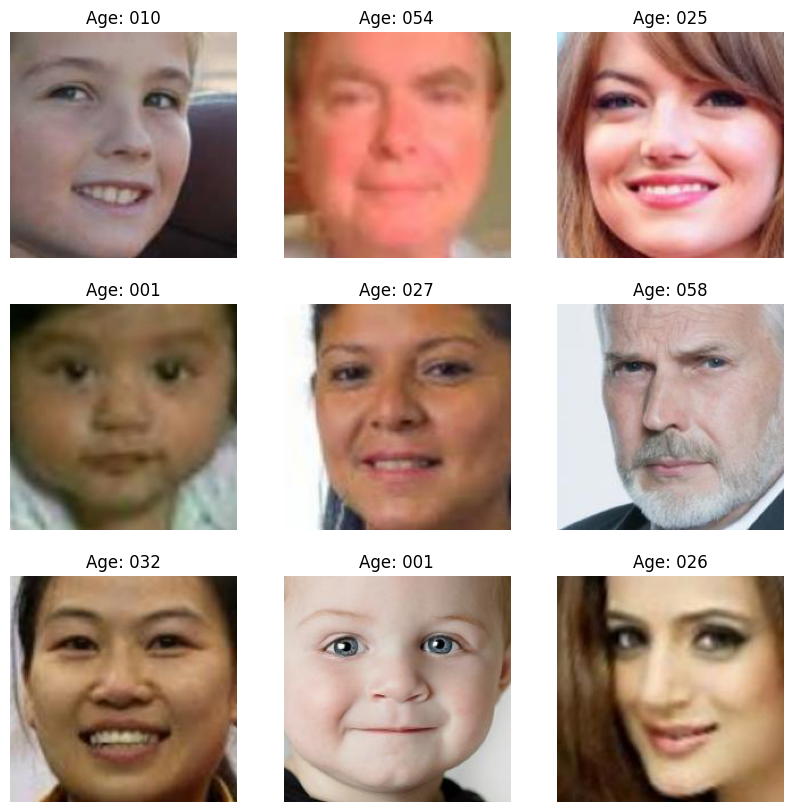

In [ ]:
import matplotlib.pyplot as plt

# Visualize a few images and their labels
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Age: {dataset.class_names[labels[i]]}")
        plt.axis("off")
plt.show()

## Data Tuning

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, shuffle=False):
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds, shuffle=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)


# MobileNet V2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

input_shape = (200, 200, 3)

# Load a lightweight feature extractor
base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg')

# Freeze the base initially
base_model.trainable = False


/tmp/ipykernel_2437/322765003.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## attempt (Ignore)

In [ ]:
# model = models.Sequential([
#     base_model,
#     layers.Dense(256, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(num_classes, activation='softmax')
# ])

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(),
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(),
#     metrics=['accuracy']
# )

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=50
# )

In [ ]:
# test_loss, test_acc = model.evaluate(test_ds)
# print(f"Test Accuracy: {test_acc:.4f}")


In [ ]:
# base_model.trainable = True

# # Re-compile with a lower learning rate
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-5),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# # Continue training
# model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=20
# )

In [ ]:
# test_loss, test_acc = model.evaluate(test_ds)
# print(f"Test Accuracy: {test_acc:.4f}")


## attempt 1

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

input_shape = (200, 200, 3)

# Load a lightweight feature extractor
base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg')

# Freeze the base initially
base_model.trainable = False

# ===================== UPDATED REGRESSION MODEL =====================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1)
])

model = models.Sequential([
    data_augmentation,
    base_model,
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='linear')  # Regression output (predicted age)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)
# ====================================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)

# ===================== FINE-TUNING STAGE =====================
# base_model.trainable = True
# for layer in base_model.layers[:100]:
#     layer.trainable = False

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-5),
#     loss='mean_squared_error',
#     metrics=['mae']
# )

# fine_tune_history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=10
# )
# =============================================================

test_loss, test_mae = model.evaluate(test_ds)
print("Test MAE:", test_mae)


/tmp/ipykernel_2437/1026165539.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg')


Epoch 1/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 51s 133ms/step - loss: 627.4266 - mae: 20.8243 - val_loss: 511.9375 - val_mae: 17.0688
Epoch 2/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 40s 128ms/step - loss: 606.6348 - mae: 20.5461 - val_loss: 341.9335 - val_mae: 15.1863
Epoch 3/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 43s 130ms/step - loss: 603.8013 - mae: 20.5391 - val_loss: 301.1473 - val_mae: 13.2790
Epoch 4/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 43s 142ms/step - loss: 596.3109 - mae: 20.3371 - val_loss: 275.4538 - val_mae: 12.6238
Epoch 5/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 43s 141ms/step - loss: 595.3554 - mae: 20.3300 - val_loss: 252.7333 - val_mae: 12.2910
Epoch 6/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - loss: 587.3782 - mae: 20.1893 - val_loss: 252.3553 - val_mae: 11.9518
Epoch 7/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 42s 143ms/step - loss: 578.6364 - mae: 20.0630 - val_loss: 250.1416 - val_mae: 11.7886
Epoch 8/25
214/214 ━━━━━━━━━━━━━━━━━━━━ 40s 131ms/step - loss: 577.5299 - mae: 20.0059 - val_loss: 241.5929 - v

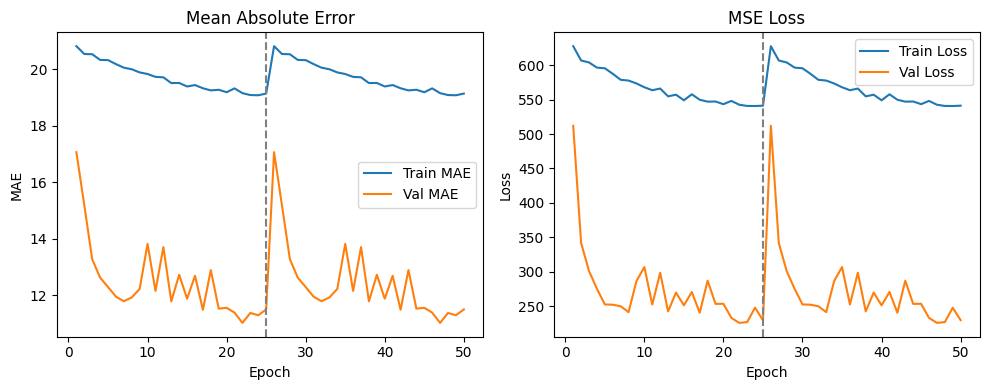

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mae = np.concatenate([history.history['mae'], history.history['mae']])
val_mae = np.concatenate([history.history['val_mae'], history.history['val_mae']])
loss = np.concatenate([history.history['loss'], history.history['loss']])
val_loss = np.concatenate([history.history['val_loss'], history.history['val_loss']])
# mae = np.concatenate([history.history['mae'], fine_tune_history.history['mae']])
# val_mae = np.concatenate([history.history['val_mae'], fine_tune_history.history['val_mae']])
# loss = np.concatenate([history.history['loss'], fine_tune_history.history['loss']])
# val_loss = np.concatenate([history.history['val_loss'], fine_tune_history.history['val_loss']])

epochs = range(1, len(mae) + 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, mae, label='Train MAE')
plt.plot(epochs, val_mae, label='Val MAE')
plt.axvline(x=len(history.history['mae']), color='gray', linestyle='--')
plt.title('Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.axvline(x=len(history.history['loss']), color='gray', linestyle='--')
plt.title('MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import os

# Define the path to save the model in Google Drive
model_save_path = '/content/drive/MyDrive/Face_Age_Prediction_v1.0_model.keras'

# Save the model in native Keras format
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: /content/drive/MyDrive/Face_Age_Prediction_v1.0_model.keras


Model loaded successfully!
Downloaded and opened image from URL: https://i.pinimg.com/736x/2f/5f/f7/2f5ff7a48dbe2cccdd9a4c95172c2fad.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Predicted Age: 25


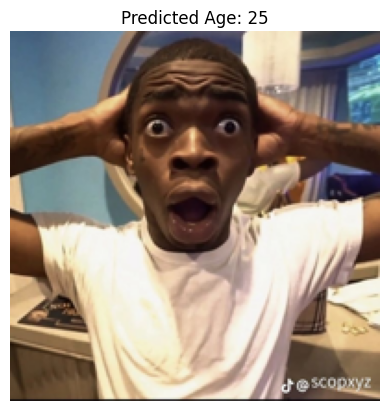

In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Define the path to the saved model
model_save_path = './Face_Age_Prediction_v1.0_model.keras'

# Load the saved model
try:
    loaded_model = tf.keras.models.load_model(model_save_path)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please ensure the model path is correct and the file exists.")
    exit()

# --- Example Usage with a Sample Image ---

# You can replace this URL with your own image path or upload an image to Colab
image_url = "https://i.pinimg.com/736x/2f/5f/f7/2f5ff7a48dbe2cccdd9a4c95172c2fad.jpg"

# Download the image
try:
    response = requests.get(image_url)
    img = Image.open(BytesIO(response.content))
    print(f"Downloaded and opened image from URL: {image_url}")
except Exception as e:
    print(f"Error downloading or opening image: {e}")
    print("Please check the image URL or provide a local path.")
    exit()

# Preprocess the image
# The model expects images of size (200, 200) and normalized to [0, 1]
image_size = (200, 200)
img = img.resize(image_size)
img_array = np.array(img)

# Ensure image has 3 channels (RGB)
if img_array.ndim == 2: # Grayscale image
    img_array = np.stack((img_array,)*3, axis=-1)
elif img_array.shape[-1] == 4: # RGBA image
    img_array = img_array[:, :, :3] # Discard alpha channel

img_array = img_array / 255.0  # Normalize to [0, 1]
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Make a prediction
prediction = loaded_model.predict(img_array)
predicted_age = int(round(prediction[0][0])) # Assuming a single age value

print(f"\nPredicted Age: {predicted_age}")

# Display the image and prediction
plt.imshow(img)
plt.title(f"Predicted Age: {predicted_age}")
plt.axis('off')
plt.show()

In [ ]:
stop


NameError: name 'stop' is not defined

# MobileNet + Objective (Evo approach)

In [ ]:
!pip install optuna --quiet

In [ ]:
import optuna
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint

def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.3, 0.6)
    freeze_until = trial.suggest_int("freeze_until", 80, 120)

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(200,200,3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False

    model = models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.1),
        base_model,
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='mean_squared_error',
        metrics=['mae']
    )

    # Removed ModelCheckpoint callback as it can cause pickling issues with Optuna
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        verbose=1
    )

    return min(history.history['val_loss'])

# study = optuna.create_study(direction="minimize")
study = optuna.create_study(study_name="facial_age_regression", storage="sqlite:////content/drive/MyDrive/facial_age_regression.db", load_if_exists=True, direction="minimize")

# study.optimize(objective, n_trials=15)

print("Best hyperparameters:", study.best_params)

In [ ]:
lr = study.best_params['lr']
dropout = study.best_params['dropout']
freeze_until = study.best_params['freeze_until']

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(200,200,3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

model = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    base_model,
    layers.Dense(256, activation='relu'),
    layers.Dropout(dropout),
    layers.Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr),
    loss='mean_squared_error',
    metrics=['mae']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,  # You can adjust the number of epochs
    verbose=1
)

# Save the model
model.save('best_trial_model.keras')

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Face Age v1.0 MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Face Age v1.0 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np

model = load_model('best_trial_model.keras')

test_loss, test_mae = model.evaluate(test_ds)
print("Test MAE:", round(test_mae, 3))

images, labels = next(iter(test_ds.unbatch().batch(8)))
preds = model.predict(images)

plt.figure(figsize=(12,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].numpy())
    plt.axis('off')
    plt.title(f"T:{int(labels[i])}  P:{int(preds[i][0])}")
plt.tight_layout()
plt.show()

In [ ]:
all_true, all_pred = [], []

for images, labels in test_ds.unbatch().batch(32):
    preds = model.predict(images, verbose=0)
    all_true.extend(labels.numpy())
    all_pred.extend(preds.squeeze())

plt.figure(figsize=(6,6))
plt.scatter(all_true, all_pred, alpha=0.5, s=10)
plt.plot([min(all_true), max(all_true)], [min(all_true), max(all_true)], 'r--')
plt.xlabel('True Age')
plt.ylabel('Predicted Age')
plt.title('True vs Predicted Age')
plt.tight_layout()
plt.show()

In [ ]:
stop



---



---



---



In [ ]:
from tensorflow.keras import layers, models

# Define a simple CNN model with Dropout
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Add dropout layer
    layers.Dense(num_classes, activation='softmax') # Output layer with num_classes units and softmax for classification
])

# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Train the model for an initial number of epochs using the augmented data
initial_epochs = 10 # You can adjust the number of epochs
history = model.fit(augmented_train_ds, validation_data=val_ds, epochs=initial_epochs)

# Display training results
print("Training History:")
print(history.history)

In [ ]:
# Run this cell to train for additional epochs

additional_epochs = 5 # adjust the number of additional epochs
history_additional = model.fit(train_ds, validation_data=val_ds, epochs=epochs + additional_epochs, initial_epoch=epochs)

# Display training results for additional epochs
print("Additional Training History:")
print(history_additional.history)

# Update initial epochs to reflect total epochs trained
epochs += additional_epochs

In [ ]:
# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)

print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

# Task
Analyze the model and data to identify the cause of the low accuracy and implement necessary changes to improve the model's performance.

## Implement data augmentation

### Subtask:
Add data augmentation layers to the model to artificially increase the size of the training dataset and introduce variations in the images.


**Reasoning**:
The subtask is to add data augmentation layers to the model. This involves importing the necessary layers, creating an augmentation model, and applying it to the training data. This can be done in a single code block.



In [ ]:
from tensorflow.keras import layers

# Create a Sequential model for data augmentation
augmentation_model = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=0.1),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
])

# Apply data augmentation to the training dataset
augmented_train_ds = train_ds.map(lambda x, y: (augmentation_model(x, training=True), y))

**Reasoning**:
The data augmentation layers have been added and applied to the training dataset. The next step is to integrate this augmented dataset into the model training process. The original model training code needs to be updated to use `augmented_train_ds`.



In [ ]:
# Define a simple CNN model (same as before)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # Output layer with num_classes units and softmax for classification
])

# Compile the model (same as before)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Train the model using the augmented training dataset
epochs = 10 # You can adjust the number of epochs
history = model.fit(augmented_train_ds, validation_data=val_ds, epochs=epochs)

print("accuracy:", history.history['accuracy'])
print("val_accuracy:", history.history['val_accuracy'])